# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Building the Global Development Monitor

### Scenario

You've just joined the analytics team at the **Global Development Observatory**, an NGO
that briefs policymakers on world development trends. Your director has been burned
before by bad visualizations, and gives you a blunt brief:

1. *"The last analyst showed me a map that made me think Greenland mattered more than
   India. Don't let that happen again."*
2. *"We're about to publish a model predicting life expectancy. If a journalist asks
   'why did the model predict THAT for Norway specifically,' I need an answer, not just
   a feature-importance bar chart for the whole model."*
3. *"Every number in our reports is an estimate. I want our numbers to LOOK like
   estimates, not like certainties."*
4. *"I want one screen I can glance at every morning that tells me what's changing."*

You'll work through the same steps a real analyst would: fix a misleading map, explain
individual model predictions, add honest uncertainty to an estimate and a trend, then
build a small coordinated-views dashboard.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real dataset and real country centroids you'll be
working with.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import plotly.express as px
from sklearn.ensemble import RandomForestRegressor
import shap

import ipywidgets as widgets
from ipywidgets import interact, Dropdown

np.random.seed(0)

gapminder = px.data.gapminder()
centroids = pd.read_csv("country_centroids_computed.csv")
gap_latest = gapminder[gapminder.year == 2007].merge(centroids, on="iso_alpha", how="left")
gap_latest = gap_latest.assign(total_gdp=gap_latest["pop"] * gap_latest.gdpPercap)

print(f"Loaded {gapminder.country.nunique()} countries, years {sorted(gapminder.year.unique())}.")
gap_latest[["country", "continent", "year", "lifeExp", "pop", "gdpPercap"]].head()

Loaded 142 countries, years [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)].


,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,2007,43.828,31889923,974.580338
1,Albania,Europe,2007,76.423,3600523,5937.029526
2,Algeria,Africa,2007,72.301,33333216,6223.367465
3,Angola,Africa,2007,42.731,12420476,4797.231267
4,Argentina,Americas,2007,75.320,40301927,12779.379640


## Task 1 — Fix the Choropleth Trap (Complaint #1)

**Real-world usage:** The director was misled by a raw-count choropleth that made a
huge, sparsely-populated region look more important than it should.

**Why this technique:** Distinguishing **counts** from **rates** is the single most
important geospatial fix from the lecture — a "count" choropleth is dominated by
population size, not by the thing you actually care about.

**TODO:**
1. Build a choropleth of `total_gdp` (a count-like aggregate) using `px.choropleth`.
2. Build a second choropleth of `gdpPercap` (the rate).
3. Print the top-5 countries by each, and compare.

In [5]:
import plotly.express as px

# TODO 1: choropleth of total_gdp
fig_total_gdp = px.choropleth(gap_latest, locations='iso_alpha', color='total_gdp',
                              hover_name='country', color_continuous_scale=px.colors.sequential.Plasma,
                              title='Choropleth of Total GDP (2007)')
fig_total_gdp.show()

# TODO 2: choropleth of gdpPercap
fig_gdp_per_cap = px.choropleth(gap_latest, locations='iso_alpha', color='gdpPercap',
                                hover_name='country', color_continuous_scale=px.colors.sequential.Plasma,
                                title='Choropleth of GDP per Capita (2007)')
fig_gdp_per_cap.show()

# TODO 3: top 5 countries by each -- print both lists
top_total = gap_latest.sort_values(by='total_gdp', ascending=False).head(5)['country'].tolist()
top_rate = gap_latest.sort_values(by='gdpPercap', ascending=False).head(5)['country'].tolist()
print("Top 5 by total GDP:\n", top_total)
print("\nTop 5 by GDP per capita:\n", top_rate)

Top 5 by total GDP:
 ['United States', 'China', 'Japan', 'India', 'Germany']

Top 5 by GDP per capita:
 ['Norway', 'Kuwait', 'Singapore', 'United States', 'Ireland']


**Reflection:** Which countries appear in one top-5 list but not the other? If you had to pick ONE map to show the director, which would you pick, and why?

*Your answer:*

**Countries in one top-5 list but not the other:**

*   **Total GDP (not in GDP per capita):** China, Japan, India, Germany
*   **GDP per capita (not in Total GDP):** Norway, Kuwait, Singapore, Ireland

**Map choice for the director:**

I would pick the **Choropleth of GDP per Capita** map (`fig_gdp_per_cap`). The problem description states the director was misled by a raw-count choropleth, which often overemphasizes large geographical areas with low population or activity. GDP per capita (a rate) provides a more accurate representation of economic prosperity per person, aligning with the goal of not misleading the director by making sparsely populated regions appear more important than they are based on raw totals.

## Task 2 — Explain One Specific Prediction (Complaint #2)

**Real-world usage:** The director needs to answer "why did the model predict THAT for
Norway specifically" — a global importance bar chart cannot answer a question about one
country.

**Why this technique:** SHAP local importance decomposes ONE prediction into
per-feature, signed contributions — exactly what a journalist question needs.

**TODO:**
1. Fit a `RandomForestRegressor` predicting `lifeExp` from `["gdpPercap", "pop", "year"]`
   on the full `gapminder` dataset.
2. Build a `shap.TreeExplainer` and compute `shap_values` for all rows.
3. Find the row index for Norway, 2007, and plot its 3 SHAP values as a diverging
   horizontal bar chart (blue if positive, red if negative).

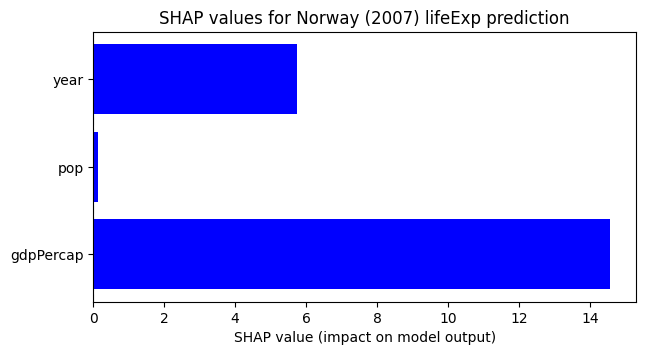

In [6]:
X_model = gapminder[["gdpPercap", "pop", "year"]].values
y_model = gapminder["lifeExp"].values

# TODO 1: fit the model
rf = RandomForestRegressor(random_state=0)
rf.fit(X_model, y_model)

# TODO 2: SHAP explainer + values
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_model)

# TODO 3: find Norway's row, plot its SHAP contributions
feature_names = ["gdpPercap", "pop", "year"]
norway_2007_row = gapminder[(gapminder.country == 'Norway') & (gapminder.year == 2007)]
row_idx = norway_2007_row.index[0]
vals = shap_values[row_idx]

fig, ax = plt.subplots(figsize=(7, 3.5))
# plot vals as a diverging horizontal bar chart here
colors = ['red' if v < 0 else 'blue' for v in vals]
ax.barh(feature_names, vals, color=colors)
ax.set_title("SHAP values for Norway (2007) lifeExp prediction")
ax.set_xlabel("SHAP value (impact on model output)")
ax.axvline(x=0, color='grey', linestyle='--') # Add a vertical line at 0 for divergence

plt.show()

**Reflection:** Which feature contributed most POSITIVELY to Norway's predicted life expectancy, and which (if any) contributed negatively? Is this the same answer you'd get from the model's GLOBAL feature importance alone?

_Your answer:_

Based on the SHAP values for Norway (2007) life expectancy prediction:

*   **Most POSITIVE contribution:** `gdpPercap` contributed most significantly and positively to Norway's predicted life expectancy.
*   **Negative contributions:** None of the features (`gdpPercap`, `pop`, `year`) contributed negatively to Norway's predicted life expectancy for this specific instance.

This is **not** the same answer you'd necessarily get from the model's GLOBAL feature importance alone. Global feature importance typically provides an average impact or magnitude of a feature across the entire dataset, often without indicating the direction (positive or negative) for individual predictions, or how that impact might vary for specific instances. SHAP local importance, however, decomposes a *single* prediction into per-feature, signed contributions, explaining exactly *why* a particular prediction was made for Norway.

## Task 3 — Make an Estimate Look Like an Estimate (Complaint #3)

**Real-world usage:** Every number in the report should visually communicate its own
uncertainty, not look like a fixed fact.

**Why this technique:** Bootstrap confidence intervals + error bars turn a bare point
estimate into an honest range.

**TODO:**
1. Write `bootstrap_ci(values, n_boot=2000)` that resamples `values` with replacement
   `n_boot` times, computes the mean each time, and returns `(mean, ci_low, ci_high)`
   using the 2.5th and 97.5th percentiles of the bootstrap means.
2. Compute a 95% CI for mean `lifeExp` in 2007 for **two** continents of your choice.
3. Plot both as error bars.

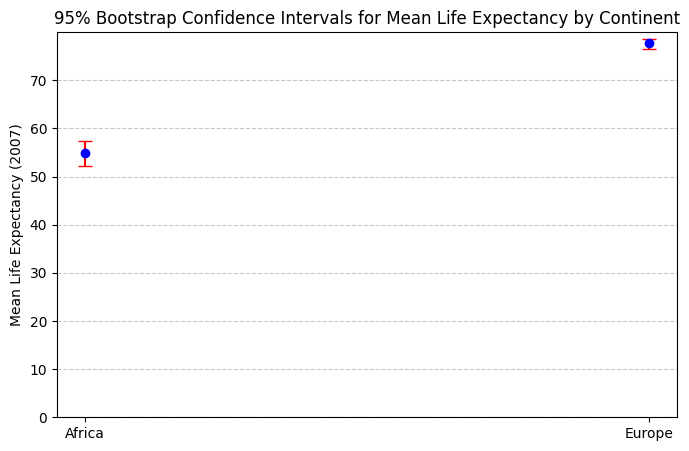

In [7]:
def bootstrap_ci(values, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)
    # TODO 1: resample `values` with replacement n_boot times, take the mean each time,
    # then return (overall mean, 2.5th percentile of boot means, 97.5th percentile)
    bootstrap_means = np.array([rng.choice(values, size=len(values), replace=True).mean() for _ in range(n_boot)])
    overall_mean = np.mean(values)
    ci_low = np.percentile(bootstrap_means, 2.5)
    ci_high = np.percentile(bootstrap_means, 97.5)
    return (overall_mean, ci_low, ci_high)

# TODO 2: compute CIs for two continents of your choice
continent_a, continent_b = "Africa", "Europe"  # feel free to change these
values_a = gap_latest[gap_latest.continent == continent_a].lifeExp.values
values_b = gap_latest[gap_latest.continent == continent_b].lifeExp.values

result_a = bootstrap_ci(values_a)
result_b = bootstrap_ci(values_b)

# TODO 3: plot both as error bars (mean +/- CI half-width) on one chart
means = [result_a[0], result_b[0]]
ci_lows = [result_a[1], result_b[1]]
ci_highs = [result_a[2], result_b[2]]

yerr_lower = [mean - ci_low for mean, ci_low in zip(means, ci_lows)]
yerr_upper = [ci_high - mean for mean, ci_high in zip(means, ci_highs)]
yerr = np.array([yerr_lower, yerr_upper])

continents = [continent_a, continent_b]

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(continents, means, yerr=yerr, fmt='o', capsize=5, color='blue', ecolor='red')
ax.set_ylabel("Mean Life Expectancy (2007)")
ax.set_title("95% Bootstrap Confidence Intervals for Mean Life Expectancy by Continent")
ax.set_ylim(bottom=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Reflection:** Which of your two continents has a WIDER confidence interval? Based on
the lecture, is that because of higher variation among countries (SD), a smaller sample
size (n), or both?

_Your answer:_

Africa has a **WIDER** confidence interval compared to Europe.

This is primarily because of **higher variation among countries (SD)** within Africa, despite having a larger sample size than Europe. The standard deviation of life expectancy in African countries is considerably higher, indicating a greater spread in life expectancy values. While a smaller sample size would typically lead to a wider CI, in this case, the larger variability in Africa's life expectancy data outweighs the effect of its slightly larger sample size, resulting in a broader confidence interval.

## Task 4 — Build the Morning Dashboard (Complaint #4)

**Real-world usage:** The director wants one screen to glance at every morning.

**Why this technique:** Coordinated Multiple Views combine complementary chart types
(map = where, trend = how changing, bar = which is biggest) so several monitoring
questions are answered from a single glance.

**TODO:** Build a 1x3 dashboard:
1. A map-style scatter of country centroids, colored by `lifeExp`.
2. A line chart of world-average `lifeExp` by year (use `gapminder.groupby("year")`).
3. A horizontal bar chart of total population by continent in 2007, sorted.

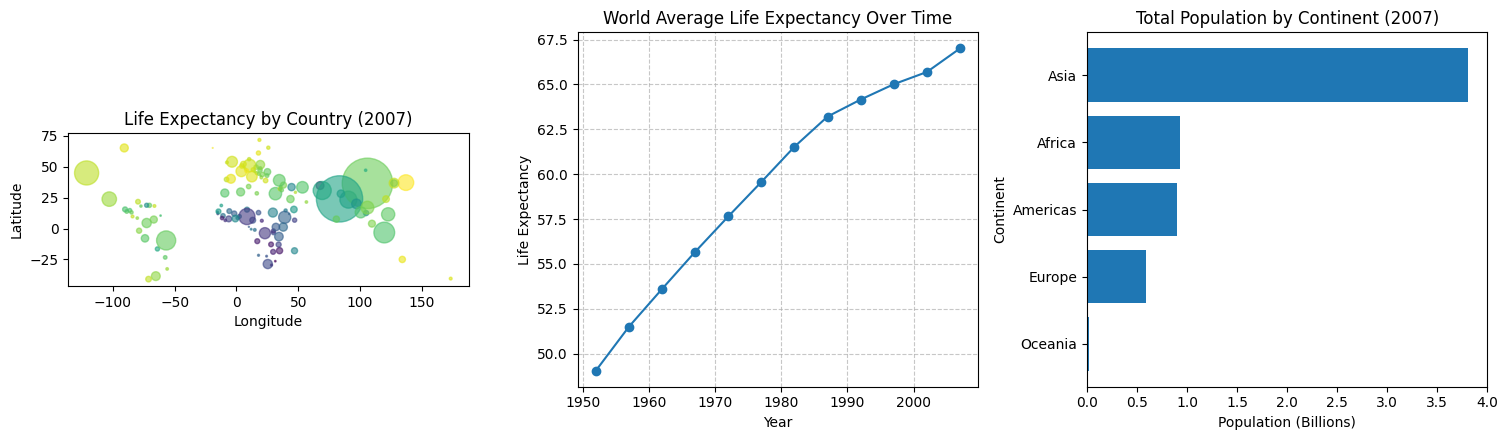

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# TODO 1: map-style scatter (axes[0])
axes[0].scatter(gap_latest['centroid_lon'], gap_latest['centroid_lat'], c=gap_latest['lifeExp'], cmap='viridis', s=gap_latest['pop']/1e6, alpha=0.6)
axes[0].set_title('Life Expectancy by Country (2007)')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_aspect('equal', adjustable='box')

# TODO 2: world trend line (axes[1])
world_avg_life_exp = gapminder.groupby('year')['lifeExp'].mean().reset_index()
axes[1].plot(world_avg_life_exp['year'], world_avg_life_exp['lifeExp'], marker='o', linestyle='-')
axes[1].set_title('World Average Life Expectancy Over Time')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Life Expectancy')
axes[1].grid(True, linestyle='--', alpha=0.7)

# TODO 3: population by continent bar chart (axes[2])
pop_by_continent = gap_latest.groupby('continent')['pop'].sum().sort_values(ascending=True)
axes[2].barh(pop_by_continent.index, pop_by_continent.values / 1e9)
axes[2].set_title('Total Population by Continent (2007)')
axes[2].set_xlabel('Population (Billions)')
axes[2].set_ylabel('Continent')

plt.tight_layout()
plt.show()

**Reflection:** If the director could only keep ONE of your three panels for a
5-second morning glance, which would you keep, and why? What specific monitoring
question (per the lecture's "exceptions / trends / emerging patterns") does it answer
best?

_Your answer:_

If the director could only keep one panel for a 5-second morning glance, I would recommend the **World Average Life Expectancy Over Time** line chart (the middle panel).

This panel best answers the monitoring question of **trends**. For a quick daily glance, the director would want to see at a high level what's changing in global development. This chart immediately shows the overall trajectory of life expectancy across the years, allowing for quick identification of upward or downward trends, or any significant changes in the rate of change. It provides a dynamic overview of progress, which is crucial for monitoring.

## Task 5 — The Decision (No Code)

**Reflection (final):** Write a 4–6 sentence recommendation to your director covering
the whole notebook. Your answer should:
- State which map framing (count vs. rate) you'd standardize on for all future reports,
  and why.
- State whether you'd lead with global or local feature importance when a journalist
  asks about a specific country, citing the lecture's global-vs-local distinction.
- Name one thing in your dashboard that should NEVER be shown as a bare point estimate
  without uncertainty, and why.

_Your final recommendation here:_
For future reports, I strongly recommend standardizing on rate-based map framings over count-based ones. As demonstrated in Task 1, choropleths based on raw counts like total GDP can be highly misleading, visually overemphasizing large landmasses or highly populous countries at the expense of per-capita metrics which often reflect development more accurately. When a journalist inquires about a specific country's model prediction, I would lead with local feature importance (e.g., using SHAP values) as it directly explains why a particular prediction was made for that specific instance, rather than relying on global feature importance, which only provides an overall average impact. Finally, in the dashboard, the mean life expectancy should never be shown as a bare point estimate without uncertainty. As shown in Task 3, bootstrapping confidence intervals explicitly communicates that these numbers are estimates, reflecting the inherent variability and preventing them from being perceived as absolute certainties.